In [13]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #51daca; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #04335a">Stokes Equations </h3>
</div>

- Stokes flow, also named creeping flow or creeping motion, is a type of fluid flow where advective inertial <br>
forces are small compared with viscous forces. The Reynolds number is low, i.e. $\displaystyle \mathrm {Re} \ll 1$. <br>
This is a typical situation in flows where the fluid velocities are very slow, the viscosities are very large, <br>
or the length-scales of the flow are very small. Creeping flow was first studied to understand lubrication. <br>
In nature, this type of flow occurs in the swimming of microorganisms and sperm. In technology, it occurs <br>
in paint, MEMS devices, and in the flow of viscous polymers generally.

$$
\begin{cases}
-\nu \Delta u + \nabla p = 0
& \text{in } \Omega, \\[0.5em]

\nabla \cdot u = 0
& \text{in } \Omega, \\[0.5em]

u = g
& \text{on } \Gamma_D, \\[0.5em]

-p\,n + \nu (\nabla u)n = h
& \text{on } \Gamma_N.
\end{cases}
$$

- Find $(u,p) \in X \times Q$ such that:

$$
\begin{cases}
\displaystyle
\int_{\Omega} \nu \nabla u : \nabla v \, d\Omega
-
\int_{\Omega} p \, (\nabla \cdot v)\, d\Omega
=
\int_{\Gamma_N} h \cdot v \, d\Gamma
-
\int_{\Omega} \nu \nabla r_g : \nabla v \, d\Omega,
& \forall v \in X,
\\[1.2em]

\displaystyle
-\int_{\Omega} q \, (\nabla \cdot u)\, d\Omega
=
\int_{\Omega} q \, (\nabla \cdot r_g)\, d\Omega,
& \forall q \in Q.
\end{cases}
$$

<div align="center">
Where:

$$
\nabla u : \nabla v
=
\sum_{i,j}
\frac{\partial u_i}{\partial x_j}
\frac{\partial v_i}{\partial x_j}
$$

 - or if we use a simplified notation:

$$
\begin{array}{cc}
\displaystyle
d(v,w)
=
\int_{\Omega}
\nu \, \nabla v : \nabla w
\, d\Omega
&
\displaystyle
b(v,q)
=
-
\int_{\Omega}
q \, (\nabla \cdot v)
\, d\Omega
\\[1.5em]

\displaystyle
f_1(w)
=
\int_{\Gamma_N}
h \cdot w
\, d\Gamma
-
d(r_g,w)
&
\displaystyle
f_2(q)
=
-
b(r_g,q)
\end{array}
$$

- Find $(u,p)\in X \times Q$ such that:

$$
\begin{cases}
d(u,v) + b(v,p)
=
f_1(v),
& \forall v \in X,
\\[1em]

b(u,q)
=
f_2(q),
& \forall q \in Q.
\end{cases}
$$

<br>
<br>
<br>

---

$$
\left[
\begin{array}{ccc}
\mathbb{A} & 0 & \mathbb{B}_x^T \\
0 & \mathbb{A} & \mathbb{B}_y^T \\
\mathbb{B}_x & \mathbb{B}_y & 0
\end{array}

\right]
\begin{bmatrix}
\mathbf{U}_x \\
\mathbf{U}_y \\
\mathbf{P}
\end{bmatrix}
=
\begin{bmatrix}
\mathbf{F}_x \\
\mathbf{F}_y \\
\mathbf{0}
\end{bmatrix}
$$

$$
\\[30pt]
\mathbb{A} \in \mathbf{R}^{N_u \times N_u} \\[13pt]
\mathbb{B}_x \in \mathbf{R}^{N_p \times N_u} \\[13pt]
\mathbb{B}_x^T \in \mathbf{R}^{N_u \times N_p}
$$

---
Imports:

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from Utilities.fem_poisson import *
from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0;  color: #11116e">Mesh </h3>
</div>

We begin with the mesh construction and refinement:

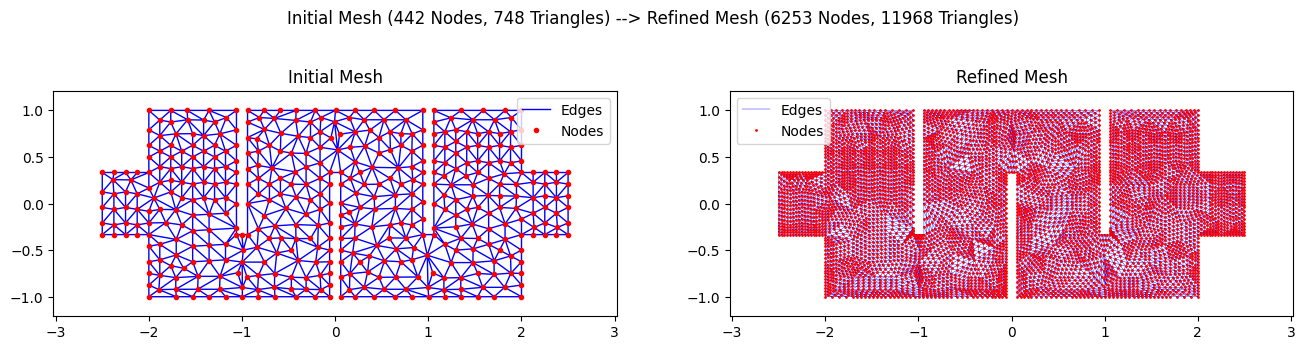

In [15]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=2, 
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [16]:
mesh_df(p_coarse, e_coarse, t_coarse, first_n_entries=13)

p is of shape: (6253, 2)
e is of shape: (18220, 3)
t is of shape: (11968, 7)


In [17]:
mesh_df(p_fine, e_fine, t_fine, first_n_entries=13)

p is of shape: (24473, 2)
e is of shape: (72344, 3)
t is of shape: (47872, 7)


---


<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">The &#120120; matrix</h3> 
</div>


$$
\begin{aligned}
A^{loc}_{ij} &= \int_T \nu (\nabla \hat{\phi_j})^T \cdot J_T^{-1}J_T^{-T} \cdot \nabla \hat{\phi_i} |J_T| d\xi_1 d\xi_2 \\
&= \frac{\nu}{2|J_T|}\cdot  (\nabla \hat{\phi_j})^T \mathbb{Q} \nabla \hat{\phi_i}
\end{aligned}
$$

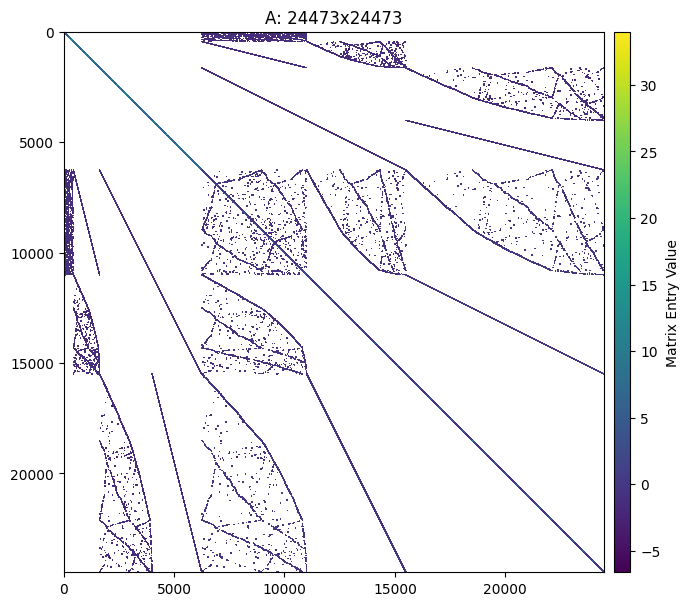

In [18]:
A = calculate_velocity_A(p_fine, t_fine, 1)
Stokes_matrix_structure(A, 'A', (7,7))

---

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">&#120121;<sub>x</sub> and &#120121;<sub>y</sub> matrices</h3>
</div>


$P_1\text{-iso-}P_1$ Mesh is used for the Stokes Equations in this demonstration.

$$
\begin{aligned}
B^x_{ij} = -\int_{\Omega}\psi _j \frac{\partial \phi _i}{\partial x} d \Omega \quad & \quad B^y_{ij} = -\int_{\Omega}\psi _j \frac{\partial \phi _i}{\partial y} d \Omega
\end{aligned}
$$

$$
\left[
    \begin{array}{c}
    \frac{\partial \phi _i}{\partial x}\\[15pt]
    \frac{\partial \phi _i}{\partial y}
    \end{array}  
\right]
= |J_T|^{-1}
\left[
    \begin{array}{c}
    \quad (y_3 - y_1)\frac{\partial \hat{\phi} _i}{\partial \xi _1} - (y_2 - y_1)\frac{\partial \hat{\phi} _i}{\partial \xi _2}\\[15pt]
    \space-(x_3 - x_1)\frac{\partial \hat{\phi} _i}{\partial \xi _1} + (x_2 - x_1)\frac{\partial \hat{\phi} _i}{\partial \xi _2}
    \end{array}  
\right]
$$

$$
\begin{aligned}
(\mathbb{B}^{loc}_x)_{ij} = \frac{1}{6} \Big((y_2 - y_1)\frac{\partial \hat{\phi} _i}{\partial \xi _2} - (y_3 - y_1)\frac{\partial \hat{\phi} _i}{\partial \xi _1} \Big) \quad & \quad (\mathbb{B}^{loc}_y)_{ij} = \frac{1}{6} \Big((x_3 - x_1)\frac{\partial \hat{\phi} _i}{\partial \xi _1} - (x_2 - x_1)\frac{\partial \hat{\phi} _i}{\partial \xi _2}\Big) 
\end{aligned}
$$

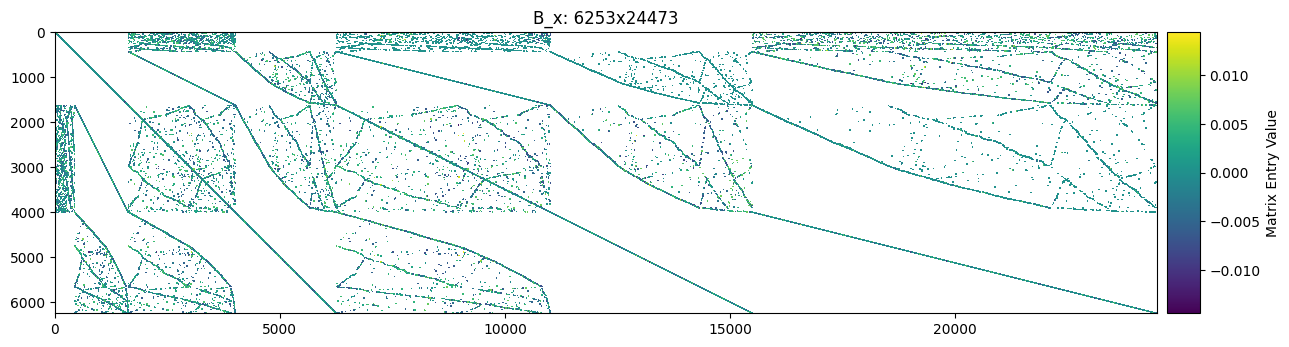

In [19]:
B_x, B_y = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
Stokes_matrix_structure(B_x, 'B_x')

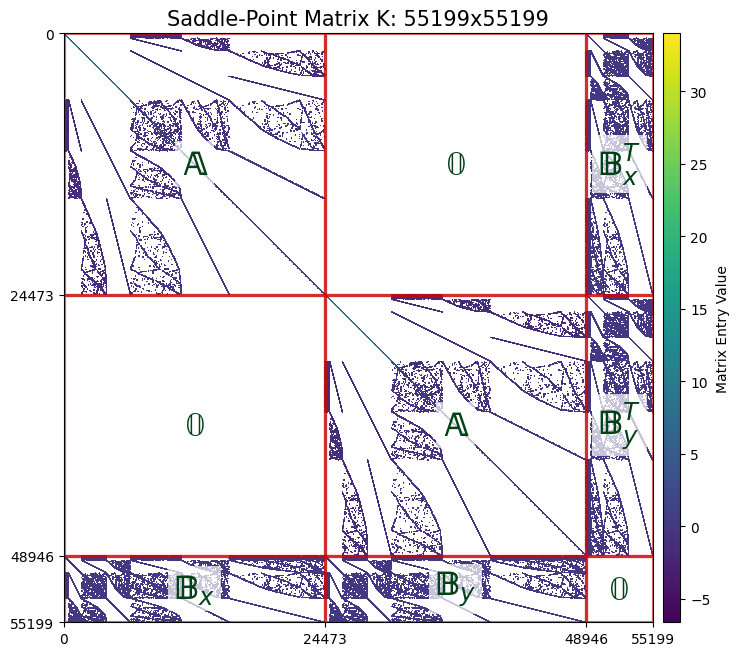

In [20]:
K = calculate_Saddle_point_K(A, B_x, B_y)
K_matrix_structure(K, A.shape[0], B_x.shape[0], (7.5,7.5))

---
We can now turn to the RHS of the system:

$$
\mathbf{F} = \int_{\Gamma_N} h \cdot v \, d\Gamma - \int_{\Omega} \nu \nabla r_g : \nabla v \, d\Omega = \mathbf{F}_{forces} - \mathbb{A}\vec{r_g} = 
\left[
    \begin{array}{c}
    \mathbb{F}_x\\
    \mathbb{F}_y
    \end{array}
\right] - \mathbb{A}\vec{r_g}
$$

$$
\mathbf{F}_{forces} =
\left[
    \begin{array}{c}
    \mathbb{F}_x\\[13pt]
    \mathbb{F}_y
    \end{array}
\right] = 
\left[
    \begin{array}{c}
    \frac{h_xL_{ij}}{2}\\[13pt]
    \frac{h_xL_{ij}}{2}
    \end{array}
\right] 
    
$$

---
Lastly we compute the pressure lift:

$$
\int_{\Omega} q \, (\nabla \cdot r_g)\, d\Omega = \int_{\Omega} q \frac{\partial r_{g,x}}{\partial x} \, d\Omega + \int_{\Omega} q \frac{\partial r_{g,y}}{\partial y} \, d\Omega \implies \mathbb{B}_x \mathbf{r}_{g,x} + \mathbb{B}_y \mathbf{r}_{g,y}
$$

---
Altogether:

$$
\mathbf{F}_{\text{global}} = 
\begin{bmatrix}
\mathbf{-\mathbb{A} \cdot \text{lf}_x} \\
\mathbf{-\mathbb{A} \cdot \text{lf}_y} \\
\mathbf{\mathbb{B}_x \cdot \text{lf}_x + \mathbb{B}_y \cdot \text{lf}_y}
\end{bmatrix}
$$

---

In [ ]:
import numpy as np
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from scipy.interpolate import griddata

def solve_stokes_final_v4(p_fine, t_fine,
                          p_coarse, t_coarse):

    Nv = p_fine.shape[0]
    Np = p_coarse.shape[0]

    eps = 1e-7

    xmin = p_fine[:,0].min()
    xmax = p_fine[:,0].max()
    ymin = p_fine[:,1].min()
    ymax = p_fine[:,1].max()

    # Find Inlet Node Indices
    is_inlet = (np.abs(p_fine[:,0] - xmin) < eps)
    inlet_idx = np.where(is_inlet)[0]

    # Find Wall Node Indices
    is_outer_wall_v = ((np.abs(p_fine[:,1] - ymax) < eps) | (np.abs(p_fine[:,1] - ymin) < eps))
    is_side_wall_v = (np.abs(p_fine[:,0] - xmax) < eps)
    is_b1v = ((np.abs(p_fine[:,0] + 1.0) < 0.06) & (p_fine[:,1] > -0.35))
    is_b2v = ((np.abs(p_fine[:,0] - 0.0) < 0.06) & (p_fine[:,1] < 0.35))
    is_b3v = ((np.abs(p_fine[:,0] - 1.0) < 0.06) & (p_fine[:,1] > -0.35))

    v_wall_idx = np.where(is_outer_wall_v | is_side_wall_v | is_b1v | is_b2v | is_b3v)[0]

    lf_x = np.zeros(Nv)
    lf_y = np.zeros(Nv)

    lf_x[inlet_idx] = -1.0  
    A = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity=100)
    Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
    F = calculate_F(A, Bx, By, (lf_x, lf_y))
    K = calculate_Saddle_point_K(A, Bx, By)

    dirichlet_nodes = np.unique(np.concatenate([inlet_idx, v_wall_idx]))
    K = K.tolil()

    for i in dirichlet_nodes:
        K[i, :] = 0.0
        K[i, i] = 1.0
        F[i] = 0.0  

        iy = i + Nv
        K[iy, :] = 0.0
        K[iy, iy] = 1.0
        F[iy] = 0.0  

    is_outlet_p = (np.abs(p_coarse[:,0] - xmax) < eps)
    p_ref_idx = np.where(is_outlet_p)[0]
    p_ref = p_ref_idx[0]
    p_row = 2 * Nv + p_ref

    K[p_row, :] = 0.0
    K[p_row, p_row] = 1.0
    F[p_row] = 0.0

    print("Solving lifted system...")
    sol = spsolve(K.tocsc(), F)

    if np.any(np.isnan(sol)):
        print("Warning: NaNs detected!")

    u0_x = sol[:Nv]
    u0_y = sol[Nv:2*Nv]
    pressure = sol[2*Nv:]

    ux = u0_x + lf_x
    uy = u0_y + lf_y

    div = Bx @ ux + By @ uy
    print("||div|| =", np.linalg.norm(div))
    print("max div =", np.max(np.abs(div)))

    return ux, uy, pressure


ux, uy, p_sol = solve_stokes_final_v4(p_fine, t_fine, p_coarse, t_coarse)

Solving lifted system...
||div|| = 0.23846419427823948
max div = 0.06076388526707816


/home/alexa/Home/UNIVERSITY/PDE_ODE/FEM/Utilities/Stokes_felib.py:287: RuntimeWarning: invalid value encountered in sqrt
  speed = np.sqrt(U**2 + V**2)


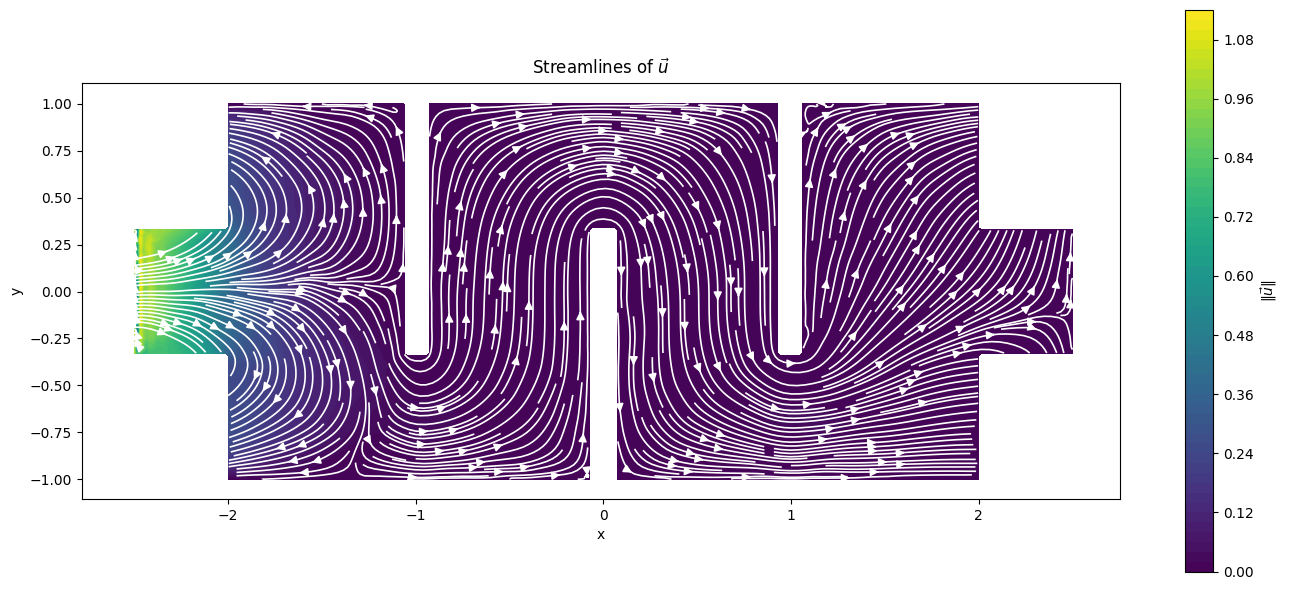

In [30]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 density=3.7)